In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv('orders.csv')
people = pd.read_csv('people.csv')
returns = pd.read_csv('returns.csv')

# Preparing Data for EDA
- Merge into a single dataset
- Convert "object" to date columns
- Handle missing values

In [25]:
orders.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2019-103800,2019-01-03,2019-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870


In [26]:
orders.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [24]:
# convert order date and ship date from objects to date
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [27]:
people.head()

,Regional Manager,Region
0,Sadie Pawthorne,West
1,Chuck Magee,East
2,Roxanne Rodriguez,Central
3,Fred Suzuki,South


In [29]:
returns.head(3)

,Returned,Order ID
0,Yes,US-2019-100762
1,Yes,US-2019-100762
2,Yes,US-2019-100762


In [143]:
# Merge different data sets
merge_data = pd.merge(orders,people,on="Region",how="outer")
merge_data = pd.merge(merge_data,returns, on="Order ID",how="outer")
merge_data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Regional Manager,Returned
0,1380,CA-2019-100867,2019-10-19,2019-10-24,Standard Class,EH-14125,Eugene Hildebrand,Home Office,Canada,Vancouver,...,TEC-PH-10004922,Technology,Phones,RCA Visys Integrated PBX 8-Line Router,32.700,3,0.0,8.5000,Sadie Pawthorne,NaN
1,1241,CA-2019-107153,2019-09-28,2019-10-03,Standard Class,GZ-14545,George Zrebassa,Corporate,Canada,Montreal,...,OFF-ST-10001321,Office Supplies,Storage,"Decoflex Hanging Personal Folder File, Blue",10.688,2,0.2,3.7408,Chuck Magee,NaN
2,62,CA-2019-115238,2019-01-21,2019-01-24,Standard Class,JW-15220,Jane Waco,Corporate,Canada,Toronto,...,FUR-FU-10001025,Furniture,Furnishings,"Eldon Imàge Series Desk Accessories, Clear",24.300,5,0.0,10.4500,Chuck Magee,NaN
3,63,CA-2019-115238,2019-01-21,2019-01-24,Standard Class,JW-15220,Jane Waco,Corporate,Canada,Toronto,...,FUR-FU-10002445,Furniture,Furnishings,"DAX Two-Tone Rosewood/Black Document Frame, De...",9.480,1,0.0,3.7900,Chuck Magee,NaN
4,64,CA-2019-115238,2019-01-21,2019-01-24,Standard Class,JW-15220,Jane Waco,Corporate,Canada,Toronto,...,FUR-FU-10002960,Furniture,Furnishings,"Eldon 200 Class Desk Accessories, Burgundy",31.400,5,0.0,13.1900,Chuck Magee,NaN


In [144]:
merge_data.isnull().sum()

Row ID                 0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country/Region         0
City                   0
State/Province         0
Postal Code            0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Regional Manager       0
Returned            9394
dtype: int64

In [145]:
merge_data['Returned'] = merge_data['Returned'].fillna('No')

In [146]:
merge_data['Returned'].tail(10).T

12610    Yes
12611    Yes
12612    Yes
12613    Yes
12614     No
12615     No
12616     No
12617     No
12618     No
12619     No
Name: Returned, dtype: object

In [147]:
# Subset the dataframe by selecting the columns we are interested in 
# Get list of column names
merge_data.columns.values.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Regional Manager',
 'Returned']

In [148]:
# Subset
merged_df = merge_data[['Ship Mode', 'Sales','Customer ID', 'Customer Name', 'Segment', 'Country/Region','City', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Discount', 'Returned']]
merged_df.head(5)

,Ship Mode,Sales,Customer ID,Customer Name,Segment,Country/Region,City,Region,Product ID,Category,Sub-Category,Discount,Returned
0,Standard Class,32.700,EH-14125,Eugene Hildebrand,Home Office,Canada,Vancouver,West,TEC-PH-10004922,Technology,Phones,0.0,No
1,Standard Class,10.688,GZ-14545,George Zrebassa,Corporate,Canada,Montreal,East,OFF-ST-10001321,Office Supplies,Storage,0.2,No
2,Standard Class,24.300,JW-15220,Jane Waco,Corporate,Canada,Toronto,East,FUR-FU-10001025,Furniture,Furnishings,0.0,No
3,Standard Class,9.480,JW-15220,Jane Waco,Corporate,Canada,Toronto,East,FUR-FU-10002445,Furniture,Furnishings,0.0,No
4,Standard Class,31.400,JW-15220,Jane Waco,Corporate,Canada,Toronto,East,FUR-FU-10002960,Furniture,Furnishings,0.0,No


# Visualizing the dataset

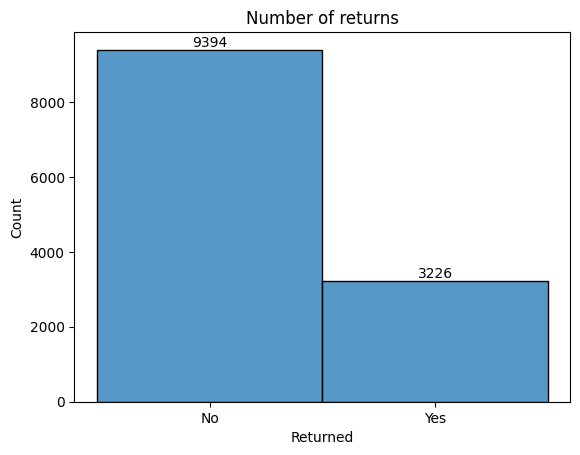

In [103]:
# View number of returns
# 25% products being returned
ax = sns.histplot(merged_df['Returned'])
ax.set_title('Number of returns')
ax.bar_label(ax.containers[0])
plt.show()

In [105]:
# Returns across regions
# 82% of returns are in West and East regions
pd.crosstab(merged_df['Region'],merged_df['Returned'])

Returned,No,Yes
Region,,
Central,2243,286
East,2837,757
South,1551,279
West,2763,1904


In [106]:
# Returns across categories
# 60% return rate in office supplies
pd.crosstab(merged_df['Category'],merged_df['Returned'])

Returned,No,Yes
Category,,
Furniture,2030,671
Office Supplies,5655,1919
Technology,1709,636


In [98]:
# Returns across discount%
# Maximum returns across 0% and 20% discount
pd.crosstab(merged_df['Discount'],merged_df['Returned'])

Returned,No,Yes
Discount,,
0.00,4524,1613
0.10,87,75
0.15,42,33
0.20,3415,1126
0.30,220,33
0.32,25,4
0.40,193,65
0.45,11,0
0.50,61,25


In [107]:
# Discount across categories
pd.crosstab(merged_df['Discount'],merged_df['Category'])

Category,Furniture,Office Supplies,Technology
Discount,,,
0.00,1048,4039,1050
0.10,142,18,2
0.15,75,0,0
0.20,802,2658,1081
0.30,246,1,6
0.32,29,0,0
0.40,100,1,157
0.45,11,0,0
0.50,74,0,12


<Axes: xlabel='Returned', ylabel='Region'>

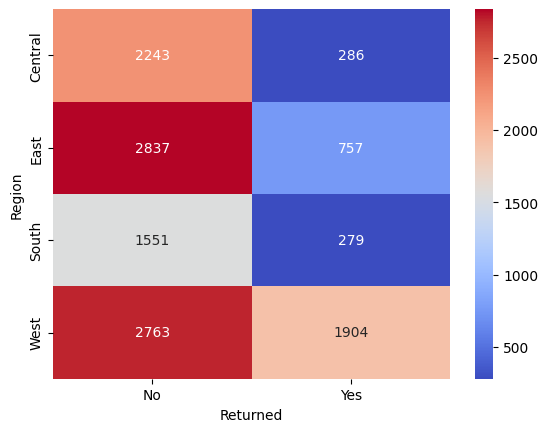

In [133]:
# Returns across categories
crosstab = pd.crosstab(merged_df['Region'],merged_df['Returned'])
sns.heatmap(crosstab,cmap='coolwarm',annot=True,fmt='d')

<Axes: xlabel='Returned', ylabel='Category'>

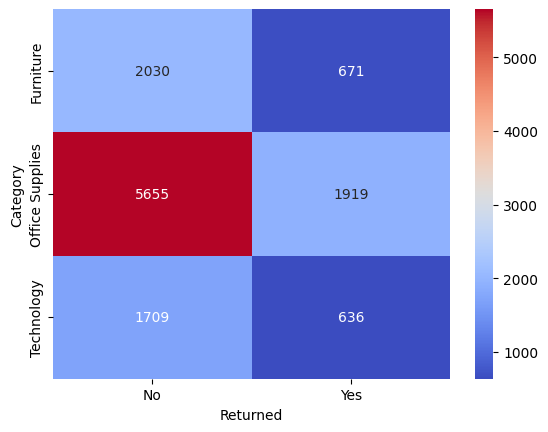

In [134]:
crosstab = pd.crosstab(merged_df['Category'],merged_df['Returned'])
sns.heatmap(crosstab,cmap='coolwarm',annot=True,fmt='d')

<Axes: xlabel='Returned', ylabel='Sub-Category'>

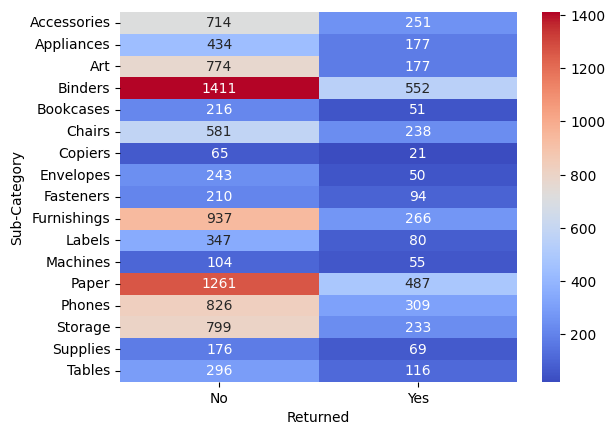

In [135]:
crosstab = pd.crosstab(merged_df['Sub-Category'],merged_df['Returned'])
sns.heatmap(crosstab,cmap='coolwarm',annot=True,fmt='d')

<Axes: xlabel='Returned', ylabel='Discount'>

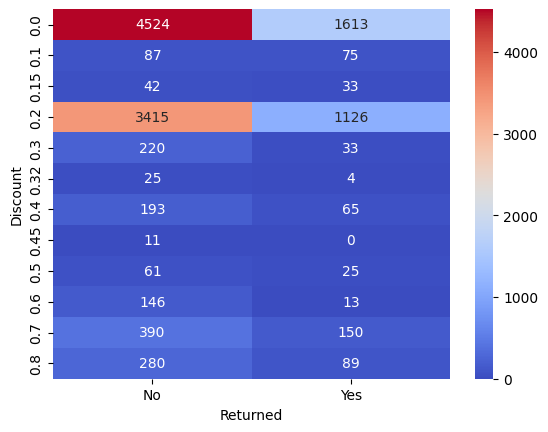

In [136]:
crosstab = pd.crosstab(merged_df['Discount'],merged_df['Returned'])
sns.heatmap(crosstab,cmap='coolwarm',annot=True,fmt='d')

<Axes: xlabel='Returned', ylabel='Country/Region'>

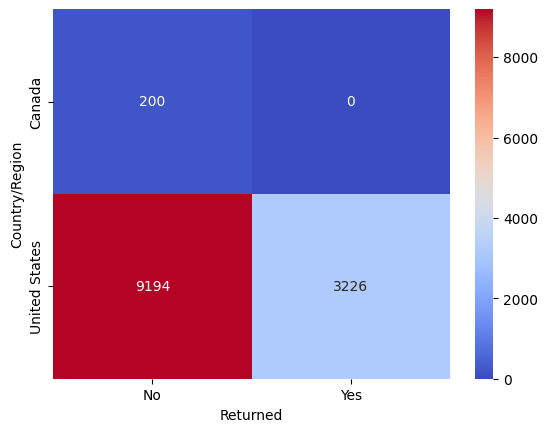

In [142]:
crosstab = pd.crosstab(merged_df['Country/Region'],merged_df['Returned'])
sns.heatmap(crosstab,cmap='coolwarm',annot=True,fmt='d')

In [156]:
returned_df = merged_df.loc[merged_df['Returned'] == 'Yes']
returned_df.head(5)

,Ship Mode,Sales,Customer ID,Customer Name,Segment,Country/Region,City,Region,Product ID,Category,Sub-Category,Discount,Returned
215,Standard Class,151.92,NG-18355,Nat Gilpin,Corporate,United States,Jackson,Central,OFF-AR-10000380,Office Supplies,Art,0.0,Yes
216,Standard Class,151.92,NG-18355,Nat Gilpin,Corporate,United States,Jackson,Central,OFF-AR-10000380,Office Supplies,Art,0.0,Yes
217,Standard Class,151.92,NG-18355,Nat Gilpin,Corporate,United States,Jackson,Central,OFF-AR-10000380,Office Supplies,Art,0.0,Yes
218,Standard Class,151.92,NG-18355,Nat Gilpin,Corporate,United States,Jackson,Central,OFF-AR-10000380,Office Supplies,Art,0.0,Yes
219,Standard Class,196.62,NG-18355,Nat Gilpin,Corporate,United States,Jackson,Central,OFF-LA-10003930,Office Supplies,Labels,0.0,Yes


In [167]:
returned_df = merged_df[merged_df['Returned'] == 'Yes']

<Axes: xlabel='City', ylabel='Count'>

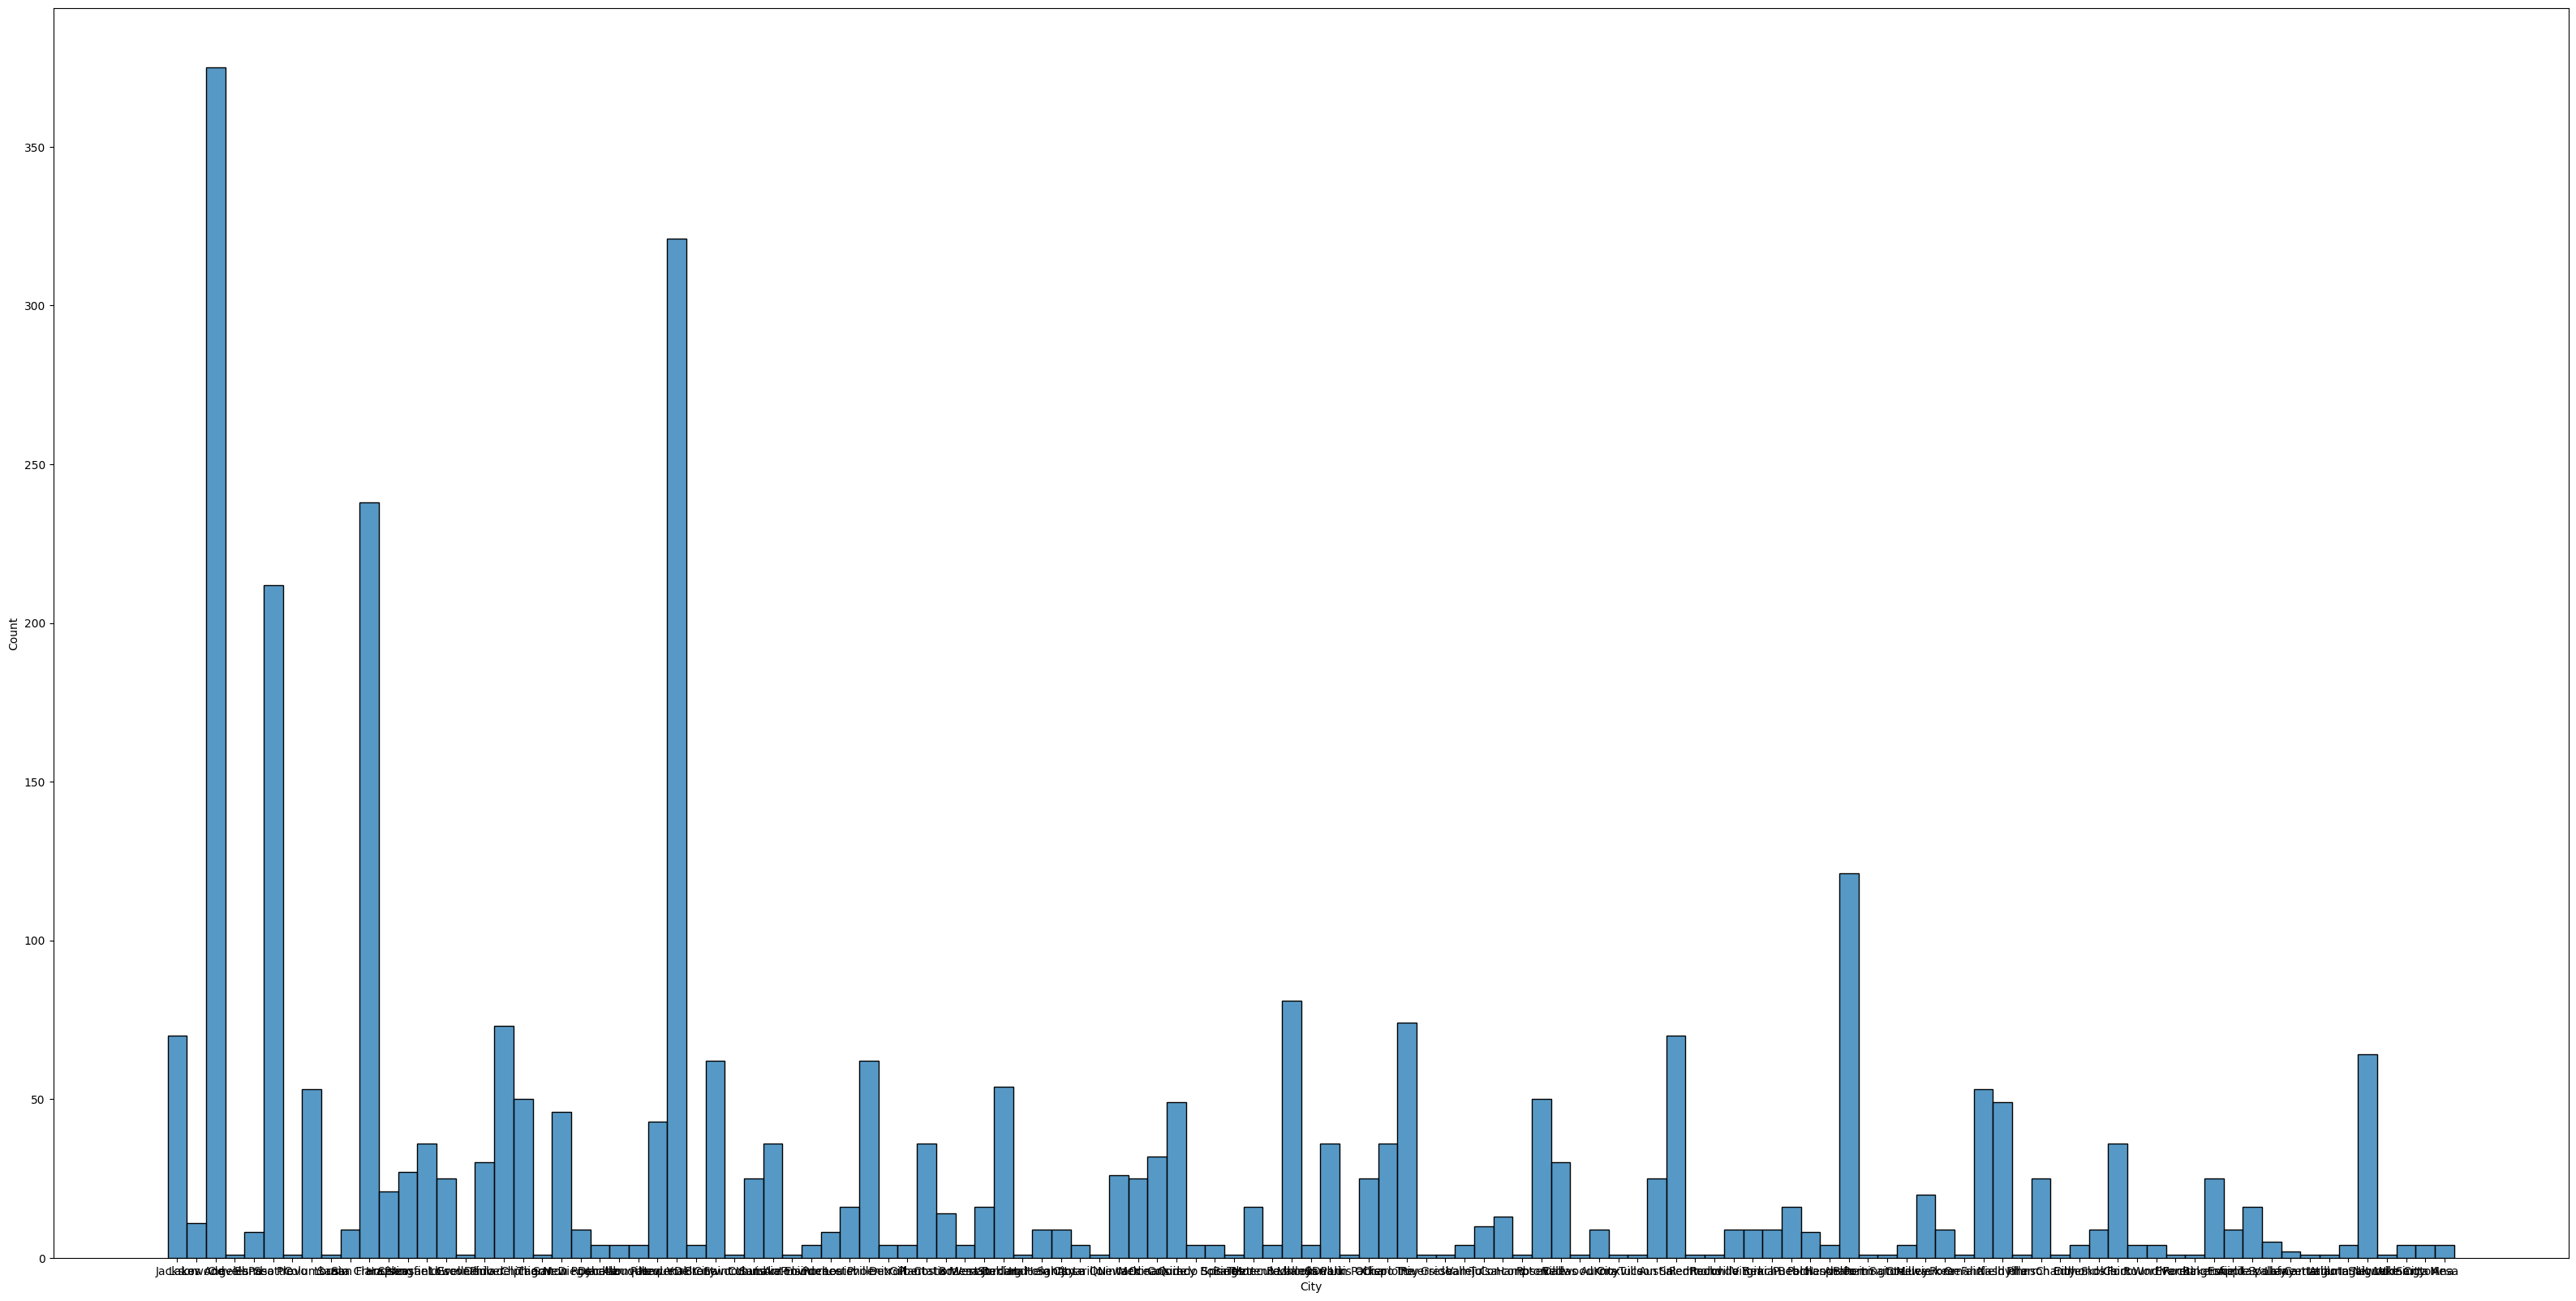

In [175]:
returned_df_city = returned_df[['City','Returned']]
plt.figure(figsize=(40, 20))
sns.histplot(returned_df_city['City'])